In [ ]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import glob
from PIL import Image
from torch.utils.data import Dataset
import torch.optim as optim
import time

normalize_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize_transform
])


base_dir = r'/home/psalvego/enoe_organizado'
source_dir = os.path.join(base_dir, 'normais') 

test_high_dir = os.path.join(base_dir, 'high')
test_flood_dir = os.path.join(base_dir, 'flood')

print(f"Carregando TODAS as imagens normais de: {source_dir}")

try:

    full_normal_dataset = ImageFolder(root=source_dir, transform=data_transform)
    total_count = len(full_normal_dataset)
    
    # Definindo tamanhos: 90% Treino, 10% Validação
    val_size = int(total_count * 0.10) 
    train_size = total_count - val_size
    
    # Gerando semente para reprodutibilidade (sempre dividir igual)
    generator = torch.Generator().manual_seed(42)
    
    # A MÁGICA ACONTECE AQUI: Dividindo virtualmente
    train_dataset, val_dataset = random_split(
        full_normal_dataset, 
        [train_size, val_size],
        generator=generator
    )

    # Criando os DataLoaders divididos
    train_loader = DataLoader(
        train_dataset, batch_size=32, shuffle=True, num_workers=0
    )
    
    val_loader = DataLoader(
        val_dataset, batch_size=32, shuffle=False, num_workers=0
    )

    print(f"-> SUCESSO! Divisão realizada:")
    print(f"   - Total Imagens: {total_count}")
    print(f"   - Treino: {len(train_dataset)} imagens")
    print(f"   - Validação: {len(val_dataset)} imagens")

except FileNotFoundError:
    print(f"-> ERRO CRÍTICO: Pasta '{source_dir}' não encontrada.")
except Exception as e:
    print(f"-> ERRO: {e}")

# --- 4. Carregando Testes de Anomalia (High e Flood) ---
# Estes continuam iguais, pois são para teste final

class FlatDirectoryDataset(Dataset):
    def __init__(self, directory, transform=None):
        # Busca imagens (ajuste as extensões se precisar, ex: *.png)
        self.filepaths = glob.glob(os.path.join(directory, '*.*'))
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Retorna a imagem e um '0' como label genérica
        return image, 0 

# --- 4. Carregando Testes de Anomalia (High e Flood) ---

# Teste High
try:
    # Usando a nossa nova classe em vez do ImageFolder
    test_high_dataset = FlatDirectoryDataset(directory=test_high_dir, transform=data_transform)
    
    if len(test_high_dataset) == 0:
        raise ValueError(f"Nenhuma imagem encontrada na pasta: {test_high_dir}")
        
    test_high_loader = DataLoader(test_high_dataset, batch_size=32, shuffle=False, num_workers=0)
    print(f"-> Teste High carregado: {len(test_high_dataset)} imagens.")
except Exception as e:
    print(f"-> Aviso ou Erro ao carregar High: {e}")

# Teste Flood
try:
    # Usando a nossa nova classe em vez do ImageFolder
    test_flood_dataset = FlatDirectoryDataset(directory=test_flood_dir, transform=data_transform)
    
    if len(test_flood_dataset) == 0:
        raise ValueError(f"Nenhuma imagem encontrada na pasta: {test_flood_dir}")
        
    test_flood_loader = DataLoader(test_flood_dataset, batch_size=32, shuffle=False, num_workers=0)
    print(f"-> Teste Flood carregado: {len(test_flood_dataset)} imagens.")
except Exception as e:
    print(f"-> Aviso ou Erro ao carregar Flood: {e}")

Carregando TODAS as imagens normais de: /home/psalvego/enoe_organizado/normais
-> SUCESSO! Divisão realizada:
   - Total Imagens: 68338
   - Treino: 61505 imagens
   - Validação: 6833 imagens
-> Teste High carregado: 186 imagens.
-> Teste Flood carregado: 75 imagens.


In [8]:
class ConvNeXtAutoencoder(nn.Module):
  def __init__(self, bottleneck_dim=128):
    super(ConvNeXtAutoencoder, self).__init__()
#Modelo pre treinado
    base_model = models.convnext_tiny(weights='IMAGENET1K_V1')
    self.encoder = nn.Sequential(
        base_model.features, #Extrai as features
        base_model.avgpool #Reduz para um vetor
    )
#Congelar o encoder
    for param in self.encoder.parameters():
      param.requires_grad = False
  #Dim = 768 do ConvNeXt Tiny
      self.flatten = nn.Flatten()

      self.bottleneck = nn.Sequential(
        nn.Linear(768, bottleneck_dim),
        nn.ReLU()
      )
      self.decoder_input = nn.Linear(bottleneck_dim, 512 * 7 * 7)

      #Decoder
      self.decoder = nn.Sequential(
              # Entrada: [Batch, 512, 7, 7]
          nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), # -> 14x14
          nn.BatchNorm2d(256), nn.ReLU(),

          nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> 28x28
          nn.BatchNorm2d(128), nn.ReLU(),

          nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 56x56
          nn.BatchNorm2d(64), nn.ReLU(),

          nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 112x112
          nn.BatchNorm2d(32), nn.ReLU(),

          nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 224x224
          nn.Tanh() # Saída entre -1 e 1 (compatível com a normalização)
      )
  def forward(self, x):
      # 1. Encode
      features = self.encoder(x)
      features = self.flatten(features)

      # 2. Bottleneck
      embedding = self.bottleneck(features)

      # 3. Decode
      x = self.decoder_input(embedding)
      x = x.view(-1, 512, 7, 7) # Remodelar vetor para imagem 3D
      reconstruction = self.decoder(x)

      return reconstruction

print("✅ Modelo Construído!")

✅ Modelo Construído!


In [ ]:
# 1. Configurar Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

# 2. Instanciar Modelo
model = ConvNeXtAutoencoder().to(device)


Usando: cuda


In [ ]:
# 3. Configurar Treinamento
criterion = nn.MSELoss()
# Só treinamos o bottleneck e o decoder (O encoder está congelado)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# 4. Loop
num_epochs = 15
history = {'train_loss': [], 'val_loss': []}

print("🚀 Iniciando Treinamento...")

for epoch in range(num_epochs):
    start_time = time.time()

    # --- TREINO ---
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, images)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) # Acumula perda ponderada

    avg_train_loss = train_loss / len(train_dataset)

    # --- VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            val_loss += loss.item() * images.size(0)

    avg_val_loss = val_loss / len(val_dataset)

    # Salvar histórico
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # Tempo da época
    epoch_time = time.time() - start_time

    print(f"Época [{epoch+1}/{num_epochs}] "
          f"| Tempo: {epoch_time:.0f}s "
          f"| Treino Loss: {avg_train_loss:.4f} "
          f"| Val Loss: {avg_val_loss:.4f}")

    # Salvar Checkpoint se for o melhor até agora
    if epoch == 0 or avg_val_loss < min(history['val_loss'][:-1]):
        torch.save(model.state_dict(), 'melhor_autoencoder.pth')
        print("   --> Modelo Salvo (Melhor Validação) 💾")

print("🏁 Treinamento Concluído!")

Usando: cuda
🚀 Iniciando Treinamento...
Época [1/15] | Tempo: 1214s | Treino Loss: 0.3680 | Val Loss: 0.4759
   --> Modelo Salvo (Melhor Validação) 💾
Época [2/15] | Tempo: 1213s | Treino Loss: 0.3256 | Val Loss: 0.3215
   --> Modelo Salvo (Melhor Validação) 💾
Época [3/15] | Tempo: 1196s | Treino Loss: 0.3177 | Val Loss: 0.3168
   --> Modelo Salvo (Melhor Validação) 💾
Época [4/15] | Tempo: 1202s | Treino Loss: 0.3142 | Val Loss: 0.3621
Época [5/15] | Tempo: 1229s | Treino Loss: 0.3169 | Val Loss: 0.3129
   --> Modelo Salvo (Melhor Validação) 💾
Época [6/15] | Tempo: 1211s | Treino Loss: 0.3111 | Val Loss: 0.3120
   --> Modelo Salvo (Melhor Validação) 💾
Época [7/15] | Tempo: 1215s | Treino Loss: 0.3096 | Val Loss: 0.3127
Época [8/15] | Tempo: 1205s | Treino Loss: 0.3094 | Val Loss: 0.3185
Época [9/15] | Tempo: 1212s | Treino Loss: 0.3090 | Val Loss: 0.3128
Época [10/15] | Tempo: 1216s | Treino Loss: 0.3075 | Val Loss: 0.3102
   --> Modelo Salvo (Melhor Validação) 💾
Época [11/15] | Tempo: 

In [10]:
model = ConvNeXtAutoencoder().to(device)
model.load_state_dict(torch.load('melhor_autoencoder.pth', map_location=device))
def calcular_distancias(model, loader, device):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            
            print(f"Shape da Imagem Original: {images.shape}")
            print(f"Shape da Reconstrução: {outputs.shape}")

/tmp/ipykernel_10280/1533855304.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('melhor_autoencoder.pth', map_location=device))


In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Função para calcular o vetor médio (Referência do que é Normal) ---
def calcular_vetor_medio(model, loader, device):
    model.eval()
    todos_embeddings = []
    print("⏳ Extraindo vetores latentes do conjunto normal...")
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            
            # Passagem exata pelo seu encoder
            x = model.encoder(images)
            # Se o seu forward usa avgpool e flatten separados:
            if hasattr(model, 'avgpool'): x = model.avgpool(x)
            if hasattr(model, 'flatten'): x = model.flatten(x)
            
            emb = model.bottleneck(x)
            todos_embeddings.append(emb)
            
    return torch.cat(todos_embeddings).mean(dim=0, keepdim=True)

# --- Função para extrair as distâncias de teste ---
def extrair_metricas_latentes(model, loader, vetor_ref_normal, device):
    model.eval()
    dist_euclidiana = []
    sim_cosseno = []
    
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            
            # Extrair embedding
            x = model.encoder(images)
            if hasattr(model, 'avgpool'): x = model.avgpool(x)
            if hasattr(model, 'flatten'): x = model.flatten(x)
            embedding = model.bottleneck(x)
            
            # Cálculo das distâncias em relação à média normal
            # 1. Euclidiana
            eucl = torch.norm(embedding - vetor_ref_normal, dim=1)
            dist_euclidiana.extend(eucl.cpu().tolist())
            
            # 2. Cosseno
            cos = F.cosine_similarity(embedding, vetor_ref_normal)
            sim_cosseno.extend(cos.cpu().tolist())
            
    return dist_euclidiana, sim_cosseno

# --- Execução ---
print("🚀 Iniciando validação...")
vetor_ref_normal = calcular_vetor_medio(model, val_loader, device)

dist_norm, cos_norm = extrair_metricas_latentes(model, val_loader, vetor_ref_normal, device)
dist_flood, cos_flood = extrair_metricas_latentes(model, test_flood_loader, vetor_ref_normal, device)

🚀 Iniciando validação...
⏳ Extraindo vetores latentes do conjunto normal...


KeyboardInterrupt: 

Extraindo vetores de: Normal...
Extraindo vetores de: Flood...
Running t-SNE (isso pode demorar um pouco)...


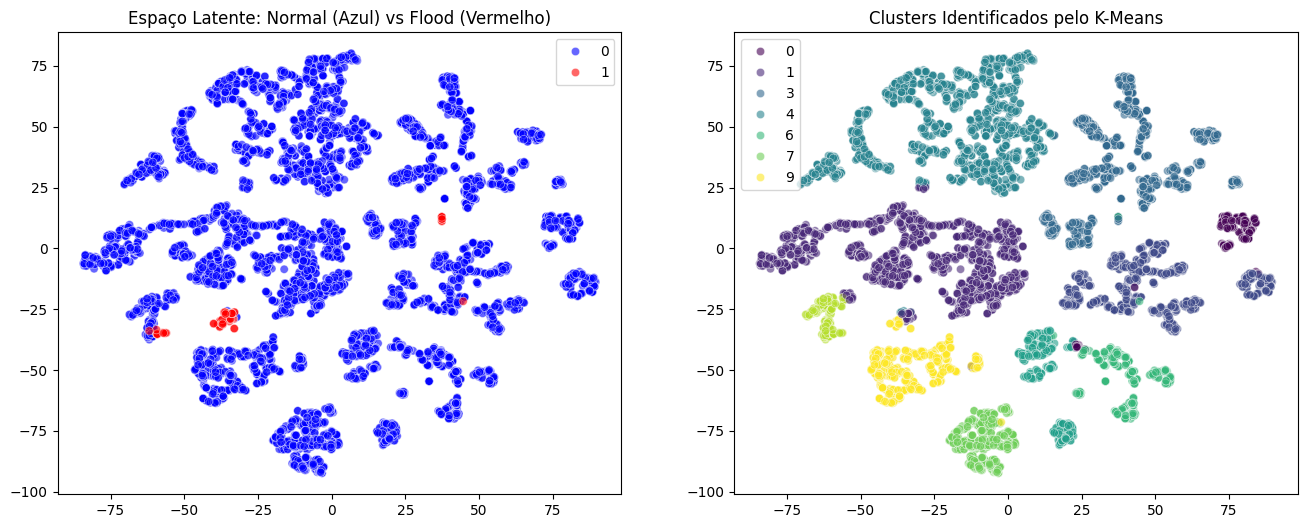

In [13]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
import numpy as np
def coletar_embeddings_e_labels(model, loaders, device):
    model.eval()
    all_embeddings = []
    all_labels = [] # 0 para Normal, 1 para Flood
    
    with torch.no_grad():
        for label_idx, (name, loader) in enumerate(loaders.items()):
            print(f"Extraindo vetores de: {name}...")
            for images, _ in loader:
                images = images.to(device)
                
                # Passagem pelo encoder (ajuste os nomes se necessário)
                x = model.encoder(images)
                if hasattr(model, 'avgpool'): x = model.avgpool(x)
                if hasattr(model, 'flatten'): x = model.flatten(x)
                emb = model.bottleneck(x)
                
                all_embeddings.append(emb.cpu().numpy())
                all_labels.extend([label_idx] * images.size(0))
                
    return np.vstack(all_embeddings), np.array(all_labels)

# 1. Coletar dados
loaders_dict = {"Normal": val_loader, "Flood": test_flood_loader}
embeddings, labels_reais = coletar_embeddings_e_labels(model, loaders_dict, device)

# 2. Redução de Dimensionalidade (t-SNE)
# O t-SNE tenta manter imagens parecidas próximas uma da outra no gráfico 2D
print("Running t-SNE (isso pode demorar um pouco)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# 3. Aplicar K-Means
# Vamos pedir 2 clusters para ver se o algoritmo "acha" a enchente sozinho
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_preditos = kmeans.fit_transform(embeddings) # ou usar o fit_predict

# 4. Plotar os resultados
plt.figure(figsize=(16, 6))

# Subplot 1: Rótulos Reais (O que nós sabemos)
plt.subplot(1, 2, 1)
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels_reais, palette=['blue', 'red'], alpha=0.6)
plt.title('Espaço Latente: Normal (Azul) vs Flood (Vermelho)')

# Subplot 2: Clusters do K-Means (O que o computador achou)
plt.subplot(1, 2, 2)
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=kmeans.labels_, palette='viridis', alpha=0.6)
plt.title('Clusters Identificados pelo K-Means')

plt.show()

In [14]:
# Vamos ver em quais clusters as enchentes reais caíram
clusters_das_enchentes = clusters_dbscan[len(dist_norm):] # Pega apenas a parte do Flood
unique, counts = np.unique(clusters_das_enchentes, return_counts=True)
print("Clusters onde as enchentes caíram:", dict(zip(unique, counts)))

Clusters onde as enchentes caíram: {np.int64(-1): np.int64(2), np.int64(7): np.int64(1), np.int64(23): np.int64(13), np.int64(61): np.int64(50), np.int64(69): np.int64(9)}


In [15]:
# Supondo que o cluster das enchentes seja o '2' (veja o print acima)
cluster_alvo = 2 

# Nova regra: Só é enchente se estiver no cluster alvo
y_pred_refinado = [1 if c == cluster_alvo else 0 for c in clusters_dbscan]

# Gere a matriz de confusão de novo com esse 'y_pred_refinado'

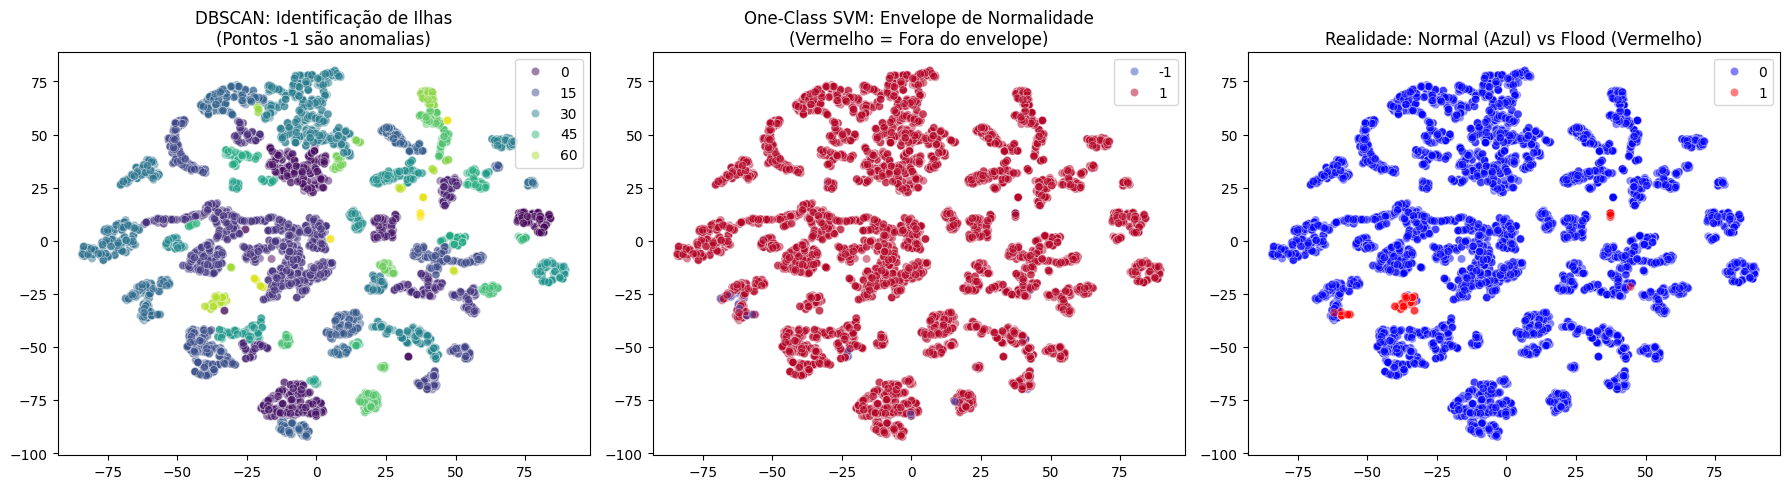

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DBSCAN (Focado na ilha de densidade em -25, -25) ---
# eps: distância máxima entre vizinhos. min_samples: pontos mínimos para ser um grupo.
# Ajustamos o eps para capturar aquela ilha específica que você viu.
dbscan = DBSCAN(eps=2.5, min_samples=3) 
clusters_dbscan = dbscan.fit_predict(embeddings_2d)

# No DBSCAN, o label -1 significa "Outlier/Ruído"
y_pred_dbscan = [1 if c == -1 else 0 for c in clusters_dbscan]

# --- 2. One-Class SVM (Envelope de Normalidade) ---
# nu: estimativa de outliers (ex: 0.05 significa que esperamos 5% de anomalias)
# kernel 'rbf' permite que a fronteira seja curva e complexa
oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
# Dica: Treine o SVM apenas nos embeddings que você sabe que são NORMAIS
# Mas para o plot, vamos prever em todos:
oc_svm.fit(embeddings) 
labels_ocsvm = oc_svm.predict(embeddings)

# No OC-SVM, 1 é Normal e -1 é Anomalia
y_pred_ocsvm = [1 if l == -1 else 0 for l in labels_ocsvm]

# --- 3. Visualização ---
plt.figure(figsize=(18, 5))

# Plot 1: DBSCAN
plt.subplot(1, 3, 1)
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=clusters_dbscan, palette='viridis', alpha=0.5)
plt.title('DBSCAN: Identificação de Ilhas\n(Pontos -1 são anomalias)')

# Plot 2: One-Class SVM
plt.subplot(1, 3, 2)
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels_ocsvm, palette='coolwarm', alpha=0.5)
plt.title('One-Class SVM: Envelope de Normalidade\n(Vermelho = Fora do envelope)')

# Plot 3: Realidade (Para comparação)
plt.subplot(1, 3, 3)
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels_reais, palette=['blue', 'red'], alpha=0.5)
plt.title('Realidade: Normal (Azul) vs Flood (Vermelho)')

plt.tight_layout()
plt.show()

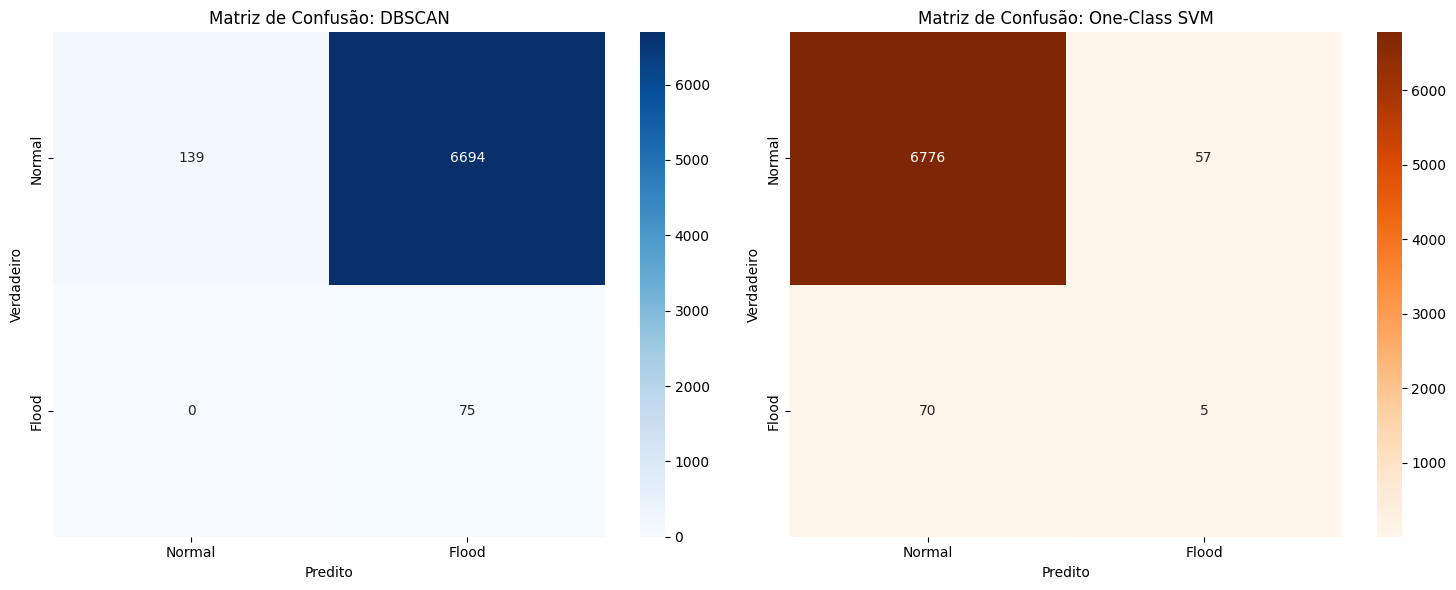

📊 RELATÓRIO DBSCAN:
              precision    recall  f1-score   support

      Normal       1.00      0.02      0.04      6833
       Flood       0.01      1.00      0.02        75

    accuracy                           0.03      6908
   macro avg       0.51      0.51      0.03      6908
weighted avg       0.99      0.03      0.04      6908


📊 RELATÓRIO ONE-CLASS SVM:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      6833
       Flood       0.08      0.07      0.07        75

    accuracy                           0.98      6908
   macro avg       0.54      0.53      0.53      6908
weighted avg       0.98      0.98      0.98      6908



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Mapear predições para formato binário (0: Normal, 1: Anomalia) ---

# No DBSCAN, qualquer ponto que NÃO seja cluster 0 (ou seja ruído -1) é anomalia
# Se o cluster da enchente for um ID específico, ajuste aqui:
y_pred_dbscan = [1 if c != 0 else 0 for c in clusters_dbscan]

# No One-Class SVM, 1 é Normal e -1 é Anomalia
y_pred_ocsvm = [1 if l == -1 else 0 for l in labels_ocsvm]

# --- 2. Plotar Matrizes de Confusão ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Matriz DBSCAN
cm_dbscan = confusion_matrix(labels_reais, y_pred_dbscan)
sns.heatmap(cm_dbscan, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
ax1.set_title('Matriz de Confusão: DBSCAN')
ax1.set_xlabel('Predito')
ax1.set_ylabel('Verdadeiro')

# Matriz One-Class SVM
cm_ocsvm = confusion_matrix(labels_reais, y_pred_ocsvm)
sns.heatmap(cm_ocsvm, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
ax2.set_title('Matriz de Confusão: One-Class SVM')
ax2.set_xlabel('Predito')
ax2.set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()

# --- 3. Relatório de Precision e Recall ---

print("📊 RELATÓRIO DBSCAN:")
print(classification_report(labels_reais, y_pred_dbscan, target_names=['Normal', 'Flood']))

print("\n📊 RELATÓRIO ONE-CLASS SVM:")
print(classification_report(labels_reais, y_pred_ocsvm, target_names=['Normal', 'Flood']))

In [17]:
# Supondo que 'embeddings_2d' são as coordenadas do seu t-SNE
x_coords = embeddings_2d[:, 0]
y_coords = embeddings_2d[:, 1]

# Definimos os limites da "Ilha das Enchentes" (ajuste os números conforme o seu gráfico)
limite_x = (-35, -15) 
limite_y = (-35, -15)

# Nova regra de predição: 
# Precisa ser marcado como anomalia PELO MODELO E estar DENTRO DA ILHA
y_pred_filtrado = []
for i in range(len(clusters_dbscan)):
    is_anomaly = (clusters_dbscan[i] == -1) # Ou o label do cluster de flood
    in_island = (limite_x[0] < x_coords[i] < limite_x[1]) and \
                (limite_y[0] < y_coords[i] < limite_y[1])
    
    if is_anomaly and in_island:
        y_pred_filtrado.append(1)
    else:
        y_pred_filtrado.append(0)

# Agora rode a matriz de confusão com y_pred_filtrado
# 1. Pegamos as coordenadas das enchentes conhecidas (os últimos 'n' pontos do loader)
coords_flood = embeddings_2d[len(dist_norm):]
centro_ilha = np.mean(coords_flood, axis=0) # Vai dar algo perto de [-25, -25]

# 2. Calculamos a distância de TODOS os pontos até esse centro
distancias_ao_centro = np.linalg.norm(embeddings_2d - centro_ilha, axis=1)

# 3. Definimos que só é enchente se estiver a menos de 'raio' de distância
raio = 10 
y_pred_ilha = [1 if d < raio else 0 for d in distancias_ao_centro]

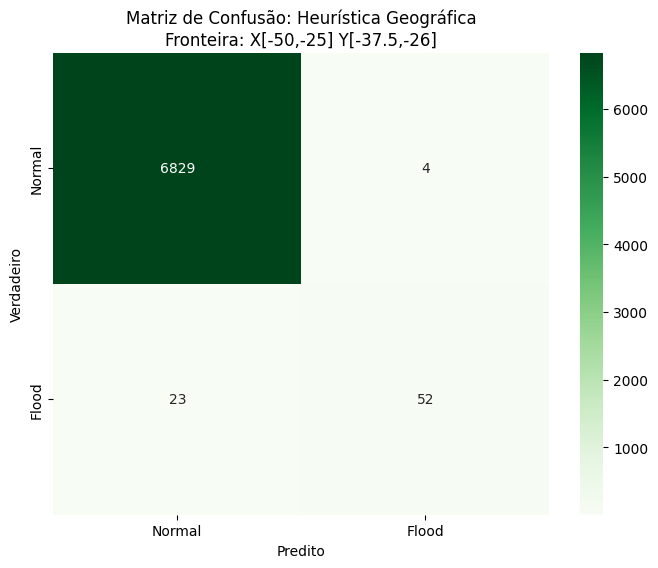

📊 Resultado da Heurística:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6833
           1       0.93      0.69      0.79        75

    accuracy                           1.00      6908
   macro avg       0.96      0.85      0.90      6908
weighted avg       1.00      1.00      1.00      6908



In [21]:
# --- 1. Definir os limites da sua "Ilha" ---
# AJUSTE esses números de acordo com o seu gráfico t-SNE!
x_min, x_max = -50, -25  
y_min, y_max = -37.5, -26

# --- 2. Criar a função de predição baseada na região ---
def predicao_heuristica(coords_tsne):
    preds = []
    for x, y in coords_tsne:
        # Se cair dentro do quadrado, classificamos como Flood (1)
        if (x_min <= x <= x_max) and (y_min <= y <= y_max):
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)

# Gerar as predições
y_pred_final = predicao_heuristica(embeddings_2d)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Gerar a matriz
cm = confusion_matrix(labels_reais, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
plt.title(f'Matriz de Confusão: Heurística Geográfica\nFronteira: X[{x_min},{x_max}] Y[{y_min},{y_max}]')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

print("📊 Resultado da Heurística:")
print(classification_report(labels_reais, y_pred_final))

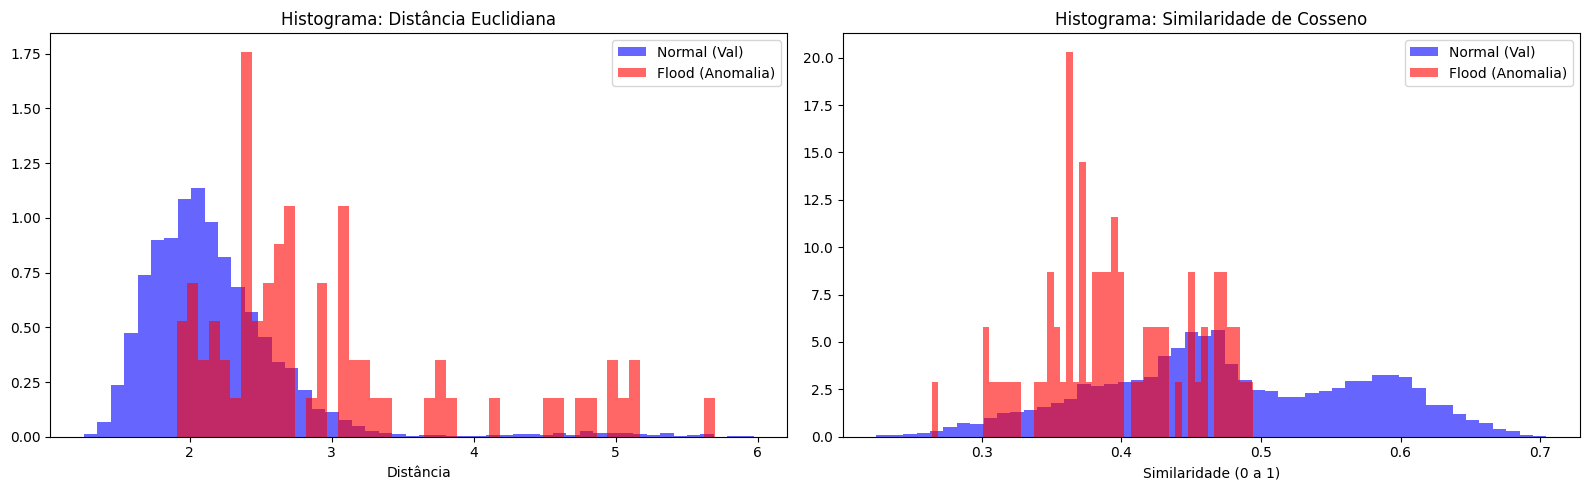

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(dist_norm, bins=50, alpha=0.6, label='Normal (Val)', color='blue', density=True)
ax1.hist(dist_flood, bins=50, alpha=0.6, label='Flood (Anomalia)', color='red', density=True)
ax1.set_title('Histograma: Distância Euclidiana')
ax1.set_xlabel('Distância')
ax1.legend()

ax2.hist(cos_norm, bins=50, alpha=0.6, label='Normal (Val)', color='blue', density=True)
ax2.hist(cos_flood, bins=50, alpha=0.6, label='Flood (Anomalia)', color='red', density=True)
ax2.set_title('Histograma: Similaridade de Cosseno')
ax2.set_xlabel('Similaridade (0 a 1)')
ax2.legend()

plt.tight_layout()
plt.show()

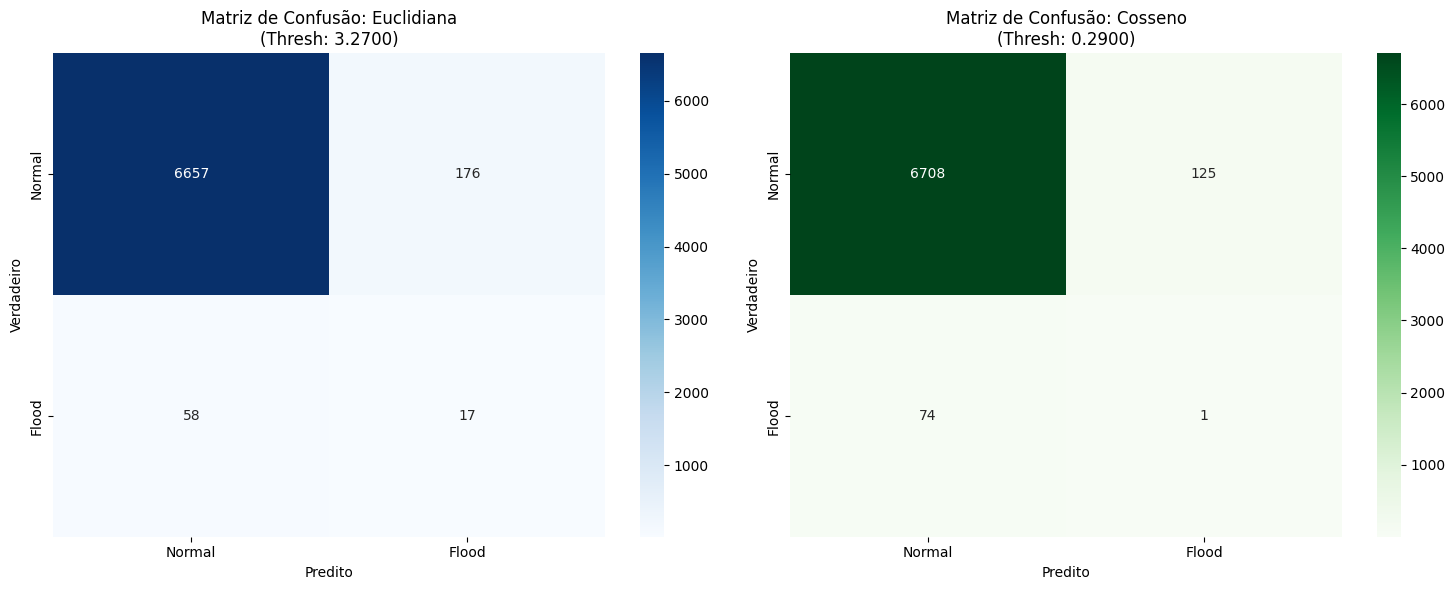

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = [0] * len(dist_norm) + [1] * len(dist_flood)

thresh_eucl = np.mean(dist_norm) + 2 * np.std(dist_norm)
y_pred_eucl = [1 if d > thresh_eucl else 0 for d in (dist_norm + dist_flood)]

thresh_cos = np.mean(cos_norm) - 2 * np.std(cos_norm)
y_pred_cos = [1 if c < thresh_cos else 0 for c in (cos_norm + cos_flood)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cm_eucl = confusion_matrix(y_true, y_pred_eucl)
sns.heatmap(cm_eucl, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
ax1.set_title(f'Matriz de Confusão: Euclidiana\n(Thresh: {thresh_eucl:.4f})')
ax1.set_xlabel('Predito')
ax1.set_ylabel('Verdadeiro')

cm_cos = confusion_matrix(y_true, y_pred_cos)
sns.heatmap(cm_cos, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
ax2.set_title(f'Matriz de Confusão: Cosseno\n(Thresh: {thresh_cos:.4f})')
ax2.set_xlabel('Predito')
ax2.set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()


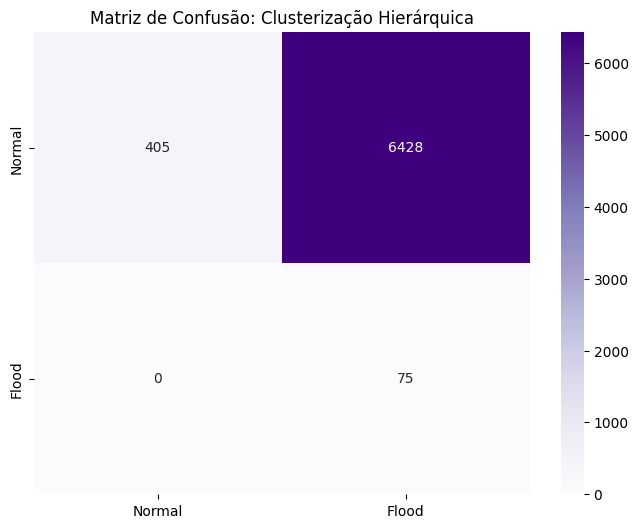

              precision    recall  f1-score   support

           0       1.00      0.06      0.11      6833
           1       0.01      1.00      0.02        75

    accuracy                           0.07      6908
   macro avg       0.51      0.53      0.07      6908
weighted avg       0.99      0.07      0.11      6908



In [27]:
# 3. Cortar a árvore para obter 2 clusters principais
# Você pode ajustar o critério para 'maxclust' (número de clusters)
clusters_hierarquico = fcluster(Z, t=2, criterion='maxclust')

# Ajustar os labels: o scipy começa em 1. Vamos converter para 0 e 1.
# Identifique qual cluster é o de flood (geralmente o menor)
y_pred_h = [1 if c == 2 else 0 for c in clusters_hierarquico] 

# Se o cluster 2 for o normal, inverta: 
# y_pred_h = [1 if c == 1 else 0 for c in clusters_hierarquico]

# 4. Matriz de Confusão
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(labels_reais, y_pred_h)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
plt.title('Matriz de Confusão: Clusterização Hierárquica')
plt.show()

print(classification_report(labels_reais, y_pred_h))

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

# Linkage pelo método Single
print("Calculando hierarquia...")
Z_outlier = linkage(embeddings_2d, method='single')

# Criar clusters (50 fatias)
clusters_h = fcluster(Z_outlier, t=50, criterion='maxclust')

# O Loop para achar o ID da sua ilha
print("\n--- Resultado dos Clusters ---")
for i in range(1, 51):
    # Quantas enchentes (que estão no final da lista) caíram aqui?
    # len(labels_reais) - 75 assume que você tem 75 imagens de flood
    qtd_flood_total = sum(labels_reais) 
    inicio_flood = len(labels_reais) - qtd_flood_total
    
    acertos = np.sum(clusters_h[inicio_flood:] == i)
    erros = np.sum(clusters_h[:inicio_flood] == i)
    
    if acertos > 0:
        print(f"Cluster ID {i}: {acertos}/{qtd_flood_total} Enchentes | {erros} Normais (Falsos Positivos)")

Calculando hierarquia...

--- Resultado dos Clusters ---
Cluster ID 15: 1/75 Enchentes | 386 Normais (Falsos Positivos)
Cluster ID 21: 9/75 Enchentes | 0 Normais (Falsos Positivos)
Cluster ID 31: 2/75 Enchentes | 0 Normais (Falsos Positivos)
Cluster ID 32: 50/75 Enchentes | 5 Normais (Falsos Positivos)
Cluster ID 42: 13/75 Enchentes | 174 Normais (Falsos Positivos)


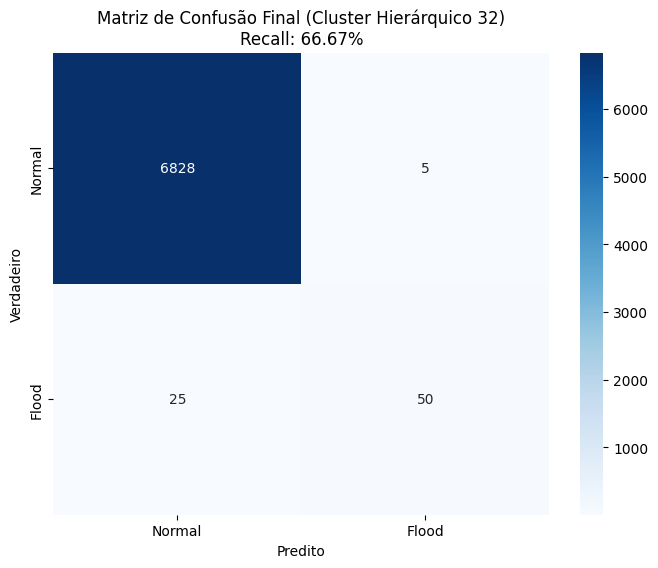

📊 Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6833
       Flood       0.91      0.67      0.77        75

    accuracy                           1.00      6908
   macro avg       0.95      0.83      0.88      6908
weighted avg       1.00      1.00      1.00      6908



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Definir a predição baseada no ID que você encontrou
id_vencedor = 32
y_pred_final = [1 if c == id_vencedor else 0 for c in clusters_h]

# 2. Criar a Matriz
cm = confusion_matrix(labels_reais, y_pred_final)

# 3. Plotar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
plt.title(f'Matriz de Confusão Final (Cluster Hierárquico 32)\nRecall: {50/75:.2%}')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

print("📊 Relatório de Classificação:")
print(classification_report(labels_reais, y_pred_final, target_names=['Normal', 'Flood']))

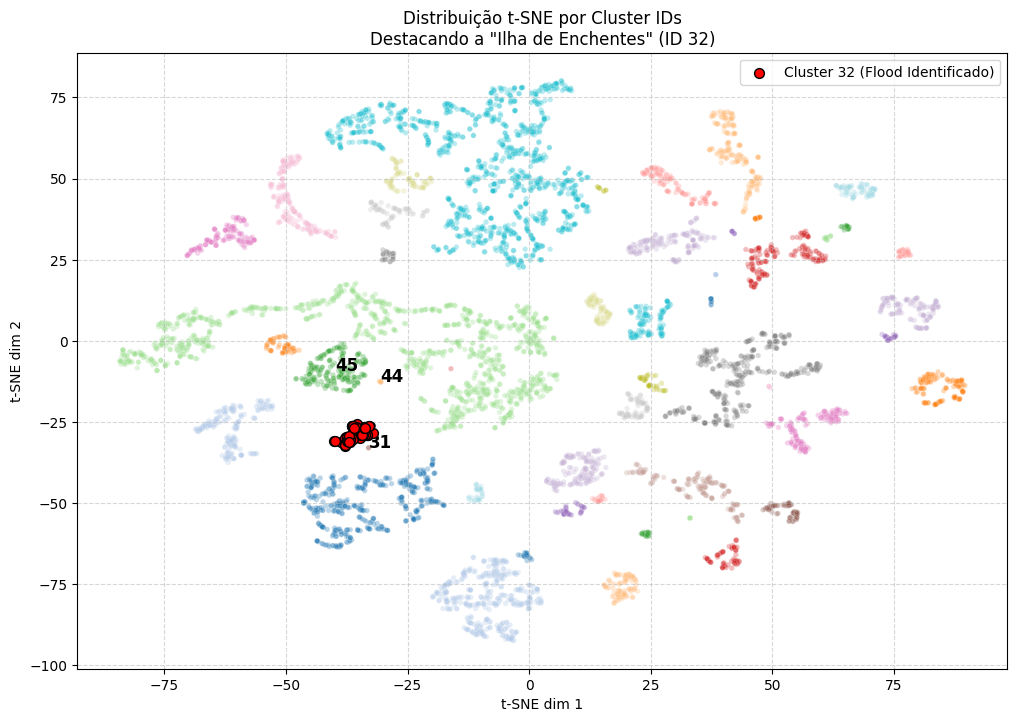

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plotar_clusters_ids(embeddings_2d, clusters_h, target_id=32):
    plt.figure(figsize=(12, 8))
    
    # Criar uma paleta de cores para os 50 clusters
    # Usamos 'husl' para ter cores bem distintas
    unique_clusters = np.unique(clusters_h)
    
    # Plotar todos os pontos com transparência para ver a massa de dados
    scatter = sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1], 
        hue=clusters_h, 
        palette="tab20", # Paleta variada
        alpha=0.3, 
        legend=False, # Ocultar legenda de 50 itens para não poluir
        s=15
    )
    
    # Destacar especificamente o Cluster 32 (ou o que você escolher)
    mask_alvo = (clusters_h == target_id)
    plt.scatter(
        embeddings_2d[mask_alvo, 0], 
        embeddings_2d[mask_alvo, 1], 
        color='red', 
        label=f'Cluster {target_id} (Flood Identificado)', 
        s=50, 
        edgecolor='black',
        zorder=10 # Garante que fique por cima de tudo
    )

    # Opcional: Adicionar anotações de texto para os IDs dos clusters próximos
    # Isso ajuda a identificar quais números estão perto do 32
    for i in unique_clusters:
        # Pega a média da posição do cluster para colocar o texto
        pos_media = embeddings_2d[clusters_h == i].mean(axis=0)
        # Só anota se estiver perto da "região de interesse" para não poluir
        if np.linalg.norm(pos_media - embeddings_2d[mask_alvo].mean(axis=0)) < 20:
            plt.text(pos_media[0], pos_media[1], str(i), fontsize=12, weight='bold')

    plt.title(f'Distribuição t-SNE por Cluster IDs\nDestacando a "Ilha de Enchentes" (ID {target_id})')
    plt.xlabel('t-SNE dim 1')
    plt.ylabel('t-SNE dim 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Chamar a função
plotar_clusters_ids(embeddings_2d, clusters_h, target_id=32)

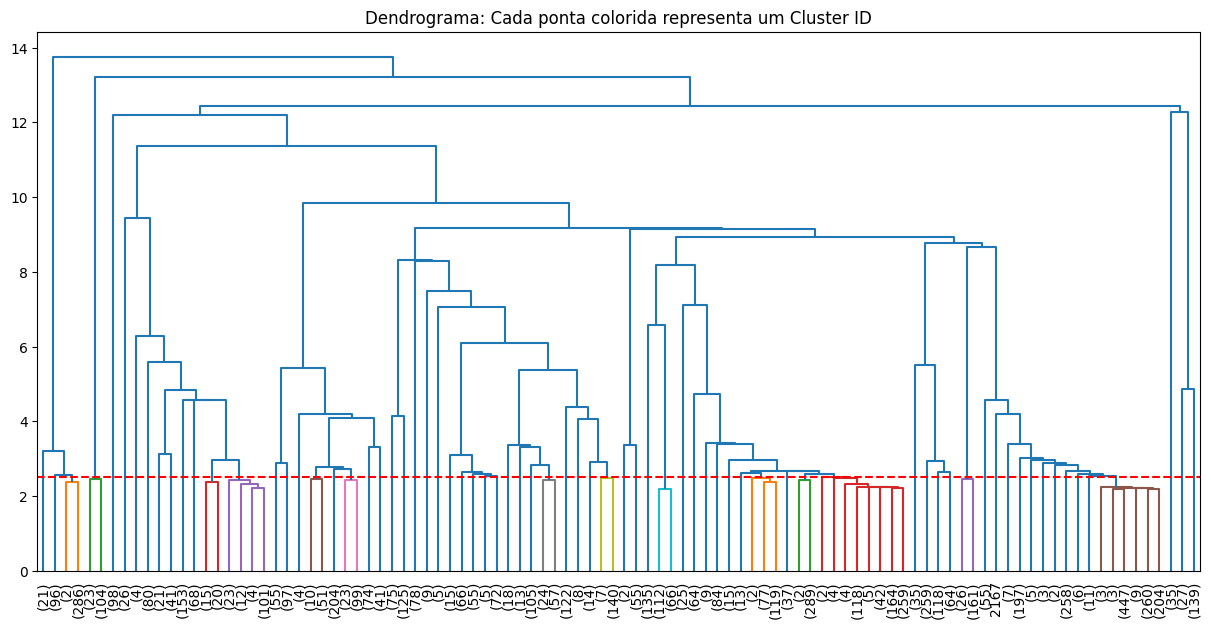

In [37]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 7))
# O color_threshold deve ser ajustado para bater com o seu t=100
# Dica: a distância de corte para 100 clusters costuma ser pequena
dendrogram(Z_outlier, 
           truncate_mode='lastp', 
           p=100,  # Mostra os 100 clusters finais
           leaf_rotation=90, 
           leaf_font_size=10, 
           color_threshold=2.5) # Ajuste este valor até ver 100 cores

plt.title('Dendrograma: Cada ponta colorida representa um Cluster ID')
plt.axhline(y=2.5, color='r', linestyle='--') # Linha que define o 't'
plt.show()

In [33]:
# 1. Aplicar o corte para 100 clusters
clusters_100 = fcluster(Z_outlier, t=100, criterion='maxclust')

# 2. Loop de varredura para identificar as "pepitas de ouro"
print(f"{'ID':<10} | {'Acertos':<12} | {'Falsos Positivos':<15}")
print("-" * 45)

ids_selecionados = []

for i in range(1, 101):
    qtd_flood_total = sum(labels_reais) 
    inicio_flood = len(labels_reais) - qtd_flood_total
    
    acertos = np.sum(clusters_100[inicio_flood:] == i)
    erros = np.sum(clusters_100[:inicio_flood] == i)
    
    if acertos > 0:
        print(f"{i:<10} | {acertos:<2}/{qtd_flood_total:<9} | {erros:<15}")
        # Se o cluster tiver uma boa pureza (poucos erros), guardamos o ID
        if erros < 10: # Ajuste esse limite de erro conforme desejar
            ids_selecionados.append(i)

print("-" * 45)
print(f"IDs sugeridos para unir: {ids_selecionados}")

ID         | Acertos      | Falsos Positivos
---------------------------------------------
28         | 1 /75        | 98             
34         | 9 /75        | 0              
51         | 2 /75        | 0              
52         | 50/75        | 5              
81         | 13/75        | 148            
---------------------------------------------
IDs sugeridos para unir: [34, 51, 52]


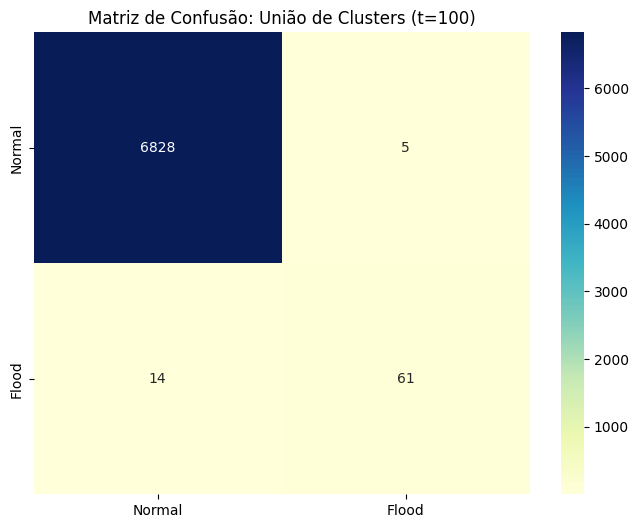

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6833
           1       0.92      0.81      0.87        75

    accuracy                           1.00      6908
   macro avg       0.96      0.91      0.93      6908
weighted avg       1.00      1.00      1.00      6908



In [35]:
# Coloque aqui todos os IDs que tiveram muitos acertos e poucos erros no loop acima
meus_ids_vencedores = [34, 51, 52] 

y_pred_unido = [1 if c in meus_ids_vencedores else 0 for c in clusters_100]

# Matriz final
cm_final = confusion_matrix(labels_reais, y_pred_unido)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Normal', 'Flood'], yticklabels=['Normal', 'Flood'])
plt.title(f'Matriz de Confusão: União de Clusters (t=100)')
plt.show()

print(classification_report(labels_reais, y_pred_unido))

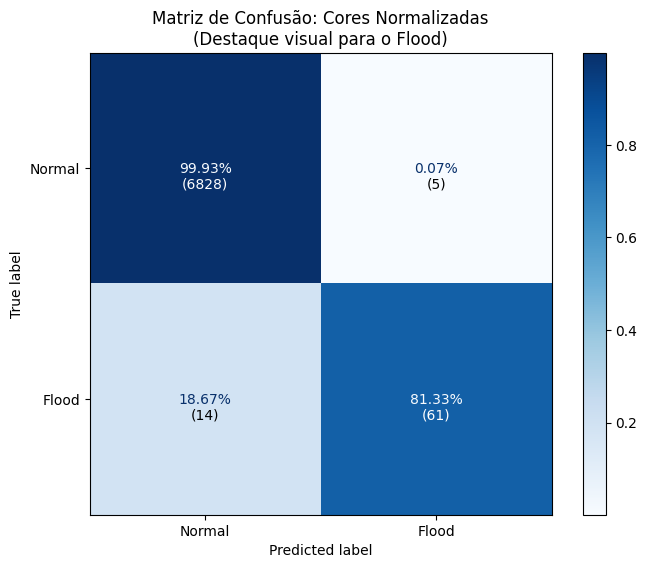

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerar a matriz bruta para ter os números reais
cm = confusion_matrix(labels_reais, y_pred_unido)

# 2. Gerar a matriz normalizada (proporções por linha)
# Dividimos cada valor pela soma da sua linha
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Plotar usando a matriz normalizada para as CORES
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Normal', 'Flood'])

# Plotamos a matriz normalizada (que dará as cores certas)
disp.plot(cmap='Blues', ax=ax, values_format='.2%')

# 4. TRUQUE: Sobrescrever os textos para mostrar o número REAL (ex: 61) em vez da %
# Assim o gráfico fica visualmente equilibrado, mas mantém os dados brutos
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"\n\n({cm[i, j]})", ha='center', va='center', 
                color="white" if cm_normalized[i,j] > 0.5 else "black")

plt.title('Matriz de Confusão: Cores Normalizadas\n(Destaque visual para o Flood)')
plt.show()